In [1]:
import pandas as pd 
import glob 

In [2]:
#md = pd.read_parquet('/share/pierson/matt/mllmsci/data/cyclomedia_manhattan_scaffolding_md.parquet')

In [3]:
#md = md[['sample_id', 'latitude', 'longitude']]

In [4]:
inference = pd.read_parquet('/share/pierson/matt/mllmsci/outputs/vqa/scaffolding/cyclomedia_20260214_181925.parquet')

In [5]:
inference = inference[['sample_id', 'recording_id', 'face', 'answer']]

In [6]:
inference.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038932 entries, 0 to 1038931
Data columns (total 4 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   sample_id     1038932 non-null  object
 1   recording_id  1038932 non-null  object
 2   face          1038932 non-null  object
 3   answer        1038932 non-null  object
dtypes: object(4)
memory usage: 31.7+ MB


In [7]:
#md = md.merge(inference[['sample_id', 'answer']], on='sample_id', how='left') 

In [8]:
#md = md.dropna(subset=['answer'])

In [10]:
recordings_md = pd.read_parquet('/share/pierson/matt/mllmsci/data/cyclomedia/recordings_manhattan_2025_md.parquet')

In [11]:
recordings_md

,imageId,lon,lat,recordedAt,productType,orientation,yawDegrees,orientationPrecision,yawPrecisionDegrees,recorderDirection,...,heightSystem,groundLevelOffset,latitudePrecision,longitudePrecision,heightPrecision,year,panoramaTileSchema,tileSchema,hasDepthMap,isAuthorized
0,W0DBPTNW,-74.008453,40.682931,2025-05-15 19:56:34.900000+00:00,Cyclorama,359.988,20625.793075,0.007,0.401070,-79.558181,...,4326,2.226012,0.007,0.006,0.012,2025,TS_100_PLUS,Dcr9Tiling,True,True
1,W0DBPTNX,-74.008512,40.682936,2025-05-15 19:56:35.850000+00:00,Cyclorama,359.988,20625.793075,0.007,0.401070,-79.558181,...,4326,2.226012,0.007,0.006,0.012,2025,TS_100_PLUS,Dcr9Tiling,True,True
2,W0DBPTNY,-74.008568,40.682924,2025-05-15 19:56:36.710000+00:00,Cyclorama,359.988,20625.793075,0.007,0.401070,-79.558181,...,4326,2.226012,0.007,0.006,0.012,2025,TS_100_PLUS,Dcr9Tiling,True,True
3,W0EGPC2O,-74.008436,40.682934,2025-09-08 20:25:15.550000+00:00,Cyclorama,359.988,20625.793075,0.007,0.401070,-79.558181,...,4326,2.226012,0.007,0.006,0.012,2025,TS_100_PLUS,Dcr9Tiling,True,True
4,W0EGPC2P,-74.008493,40.682941,2025-09-08 20:25:16.630000+00:00,Cyclorama,359.988,20625.793075,0.007,0.401070,-79.558181,...,4326,2.226012,0.007,0.006,0.012,2025,TS_100_PLUS,Dcr9Tiling,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135234,W0ENGD59,-73.908707,40.877590,2025-09-29 14:55:52.610000+00:00,Cyclorama,359.958,20624.074202,0.009,0.515662,-46.289318,...,4326,2.225929,0.010,0.011,0.024,2025,TS_100_PLUS,Dcr9Tiling,True,True
135235,W0ENGD5B,-73.908742,40.877553,2025-09-29 14:55:53.390000+00:00,Cyclorama,359.958,20624.074202,0.009,0.515662,-46.289318,...,4326,2.225929,0.010,0.011,0.024,2025,TS_100_PLUS,Dcr9Tiling,True,True
135236,W0ENGD5D,-73.908778,40.877517,2025-09-29 14:55:54.160000+00:00,Cyclorama,359.958,20624.074202,0.009,0.515662,-46.289318,...,4326,2.225929,0.010,0.011,0.024,2025,TS_100_PLUS,Dcr9Tiling,True,True
135237,W0ENGE3J,-73.908039,40.878178,2025-09-29 15:17:42.260000+00:00,Cyclorama,359.958,20624.074202,0.009,0.515662,-46.289318,...,4326,2.225929,0.010,0.011,0.024,2025,TS_100_PLUS,Dcr9Tiling,True,True


In [12]:
inference = inference.merge(recordings_md, left_on='recording_id', right_on='imageId', how='left')

In [13]:
inference.info()
inference.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038932 entries, 0 to 1038931
Data columns (total 28 columns):
 #   Column                Non-Null Count    Dtype              
---  ------                --------------    -----              
 0   sample_id             1038932 non-null  object             
 1   recording_id          1038932 non-null  object             
 2   face                  1038932 non-null  object             
 3   answer                1038932 non-null  object             
 4   imageId               1038932 non-null  object             
 5   lon                   1038932 non-null  float64            
 6   lat                   1038932 non-null  float64            
 7   recordedAt            1038932 non-null  datetime64[ns, UTC]
 8   productType           1038932 non-null  object             
 9   orientation           1038932 non-null  float64            
 10  yawDegrees            1038932 non-null  float64            
 11  orientationPrecision  1038932 non-nul

,sample_id,recording_id,face,answer,imageId,lon,lat,recordedAt,productType,orientation,...,heightSystem,groundLevelOffset,latitudePrecision,longitudePrecision,heightPrecision,year,panoramaTileSchema,tileSchema,hasDepthMap,isAuthorized
0,W0ELLNGS_B,W0ELLNGS,B,No,W0ELLNGS,-73.970147,40.806333,2025-09-22 14:58:19+00:00,Cyclorama,0.028,...,4326,2.226012,0.008,0.009,0.013,2025,TS_100_PLUS,Dcr9Tiling,True,True
1,W0ELLLMF_F,W0ELLLMF,F,No,W0ELLLMF,-73.986234,40.782455,2025-09-22 14:44:56.170000+00:00,Cyclorama,0.037,...,4326,2.226012,0.008,0.009,0.014,2025,TS_100_PLUS,Dcr9Tiling,True,True
2,W0ELLLMF_L,W0ELLLMF,L,No,W0ELLLMF,-73.986234,40.782455,2025-09-22 14:44:56.170000+00:00,Cyclorama,0.037,...,4326,2.226012,0.008,0.009,0.014,2025,TS_100_PLUS,Dcr9Tiling,True,True
3,W0ELLLMF_R,W0ELLLMF,R,No,W0ELLLMF,-73.986234,40.782455,2025-09-22 14:44:56.170000+00:00,Cyclorama,0.037,...,4326,2.226012,0.008,0.009,0.014,2025,TS_100_PLUS,Dcr9Tiling,True,True
4,W0ELLLMF_B,W0ELLLMF,B,No,W0ELLLMF,-73.986234,40.782455,2025-09-22 14:44:56.170000+00:00,Cyclorama,0.037,...,4326,2.226012,0.008,0.009,0.014,2025,TS_100_PLUS,Dcr9Tiling,True,True


In [14]:
inference['month'] = pd.to_datetime(inference['recordedAt']).dt.month
inference['month'].value_counts()

month
8     520825
9     486165
10     31942
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt
import geopandas as gpd

In [17]:
inference = gpd.GeoDataFrame(inference, geometry=gpd.points_from_xy(inference.statePlaneX, inference.statePlaneY))
inference.crs = {'init': 'epsg:2263'}


/share/pierson/matt/mllmsci/.venv/lib/python3.11/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


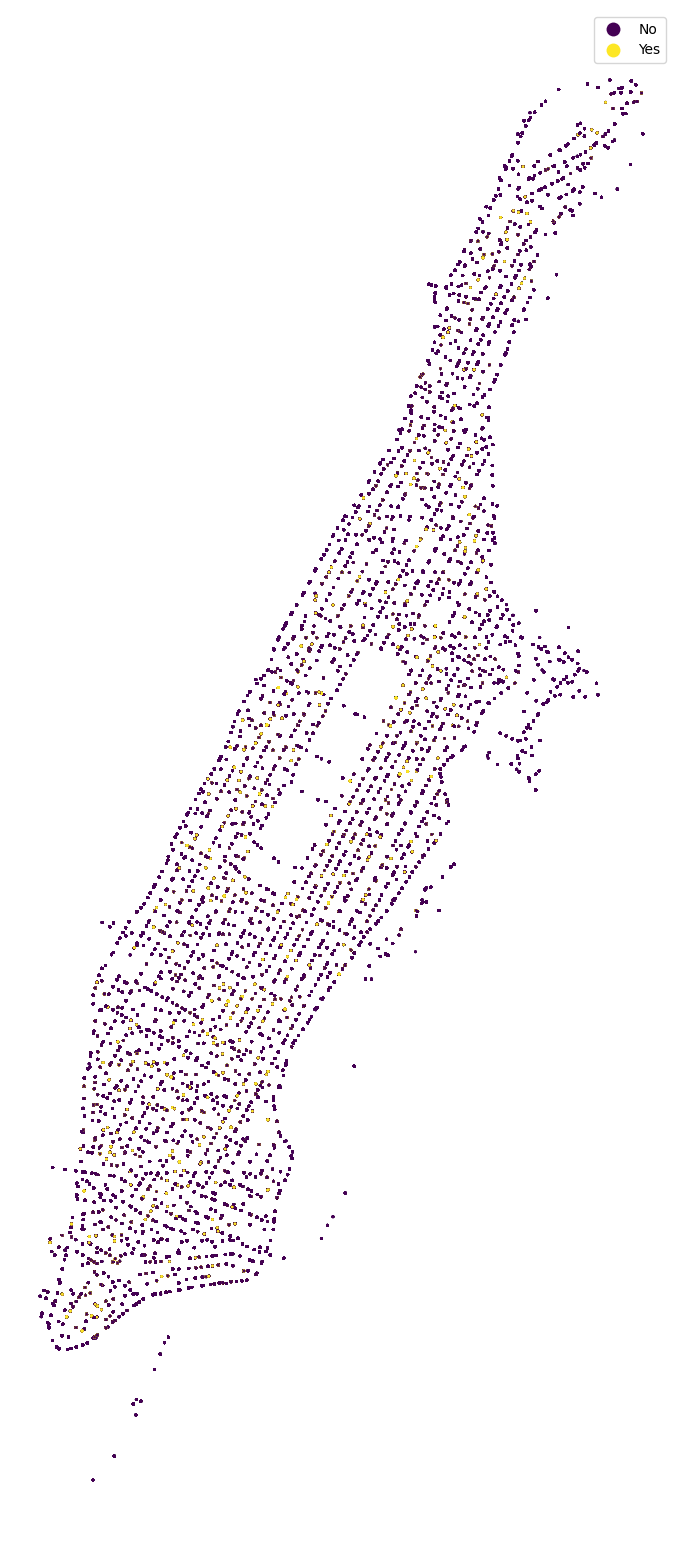

In [22]:
fig, ax = plt.subplots(figsize=(20, 20))

inference.plot(ax=ax, column='answer', cmap='viridis', legend=True, markersize=1, alpha=1)

ax.set_axis_off()
